## Enterprise Revenue & Operational Performance Diagnostics 
### Data Preprocessing


In [1]:
import pandas as pd
import numpy as np
import os



In [2]:
  
orders       = pd.read_csv("data/olist_orders_dataset.csv")
order_items  = pd.read_csv("data/olist_order_items_dataset.csv")
payments     = pd.read_csv("data/olist_order_payments_dataset.csv")
reviews      = pd.read_csv("data/olist_order_reviews_dataset.csv")
customers    = pd.read_csv("data/olist_customers_dataset.csv")
sellers      = pd.read_csv("data/olist_sellers_dataset.csv")
products     = pd.read_csv("data/olist_products_dataset.csv")
geo          = pd.read_csv("data/olist_geolocation_dataset.csv")
category_map = pd.read_csv("data/product_category_name_translation.csv")


print("Orders:", orders.shape)
print("Order Items:", order_items.shape)
print("Payments:", payments.shape)
print("Reviews:", reviews.shape)
print("Customers:", customers.shape)
print("Sellers:", sellers.shape)
print("Products:", products.shape)
print("Geolocation:", geo.shape)
print("Category Mapping:", category_map.shape)


Orders: (99441, 8)
Order Items: (112650, 7)
Payments: (103886, 5)
Reviews: (99224, 7)
Customers: (99441, 5)
Sellers: (3095, 4)
Products: (32951, 9)
Geolocation: (1000163, 5)
Category Mapping: (71, 2)


In [3]:

print("Column types:")
print(orders.dtypes)
orders.head()

Column types:
order_id                         str
customer_id                      str
order_status                     str
order_purchase_timestamp         str
order_approved_at                str
order_delivered_carrier_date     str
order_delivered_customer_date    str
order_estimated_delivery_date    str
dtype: object


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [4]:
print("Null values")
tables = {
    "orders": orders,
    "order_items": order_items,
    "payments": payments,
    "reviews": reviews,
    "customers": customers,
    "sellers": sellers,
    "products": products
}

for name, df in tables.items():
    nulls = df.isnull().sum()
    nulls = nulls[nulls > 0]
    if len(nulls) > 0:
        print(f"{name}:")
        for col, count in nulls.items():
            pct = 100 * count / len(df)
            print(f"  {col}: {count} nulls ({pct:.1f}%)")
    else:
        print(f"{name}:0")


Null values
orders:
  order_approved_at: 160 nulls (0.2%)
  order_delivered_carrier_date: 1783 nulls (1.8%)
  order_delivered_customer_date: 2965 nulls (3.0%)
order_items:0
payments:0
reviews:
  review_comment_title: 87656 nulls (88.3%)
  review_comment_message: 58247 nulls (58.7%)
customers:0
sellers:0
products:
  product_category_name: 610 nulls (1.9%)
  product_name_lenght: 610 nulls (1.9%)
  product_description_lenght: 610 nulls (1.9%)
  product_photos_qty: 610 nulls (1.9%)
  product_weight_g: 2 nulls (0.0%)
  product_length_cm: 2 nulls (0.0%)
  product_height_cm: 2 nulls (0.0%)
  product_width_cm: 2 nulls (0.0%)


In [5]:
print("Order Status Distribution:")
print(orders['order_status'].value_counts())
print()
print(f"Total orders: {len(orders):,}")


Order Status Distribution:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

Total orders: 99,441


In [6]:
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
print("Date range of orders:")
print(f"  Earliest: {orders['order_purchase_timestamp'].min()}")
print(f"  Latest  : {orders['order_purchase_timestamp'].max()}")


Date range of orders:
  Earliest: 2016-09-04 21:15:19
  Latest  : 2018-10-17 17:30:18


In [7]:
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

# Drop the tiny number of rows with no purchase timestamp
before = len(orders)
orders.dropna(subset=['order_purchase_timestamp'], inplace=True)
after = len(orders)
print(f"Rows dropped (no purchase timestamp): {before - after}")
print(f"Orders remaining: {after:,}")
print()
print("Date columns now correctly typed:")
print(orders[date_cols].dtypes)


Rows dropped (no purchase timestamp): 0
Orders remaining: 99,441

Date columns now correctly typed:
order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object


In [8]:
before = len(order_items)
order_items.dropna(subset=['order_id', 'seller_id', 'price'], inplace=True)
after = len(order_items)
print(f"Rows dropped: {before - after}")
print(f"Order items remaining: {after}")
print()
order_items.head()


Rows dropped: 0
Order items remaining: 112650



,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [9]:
order_items.dtypes

order_id                   str
order_item_id            int64
product_id                 str
seller_id                  str
shipping_limit_date        str
price                  float64
freight_value          float64
dtype: object

Clean & Aggregate Payments Table
One order can have multiple payment rows (e.g. credit card + voucher).
We aggregate them into one row per order so joining is clean.


In [10]:
# Aggregate: one row per order
payments_clean = payments.groupby('order_id').agg(
    total_payment        = ('payment_value', 'sum'),
    payment_installments = ('payment_installments', 'max'),
    payment_type         = ('payment_type', lambda x: x.mode()[0])
).reset_index()

print(f"Payments before aggregation : {len(payments):,} rows")
print(f"Payments after aggregation  : {len(payments_clean):,} rows (one per order)")
print()
print("Payment type distribution:")
print(payments['payment_type'].value_counts())


Payments before aggregation : 103,886 rows
Payments after aggregation  : 99,440 rows (one per order)

Payment type distribution:
payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64


In [11]:
reviews['review_creation_date'] = pd.to_datetime(reviews['review_creation_date'])

# Keep latest review per order
reviews_clean = (reviews
    .sort_values('review_creation_date')
    .drop_duplicates(subset='order_id', keep='last')
)

print(f"Reviews before dedup : {len(reviews):,}")
print(f"Reviews after dedup  : {len(reviews_clean):,}")
print()
print("Review score distribution:")
print(reviews_clean['review_score'].value_counts().sort_index())


Reviews before dedup : 99,224
Reviews after dedup  : 98,673

Review score distribution:
review_score
1    11365
2     3130
3     8134
4    19043
5    57001
Name: count, dtype: int64


In [12]:
# Join English category names
products_clean = products.merge(category_map, on='product_category_name', how='left')
products_clean['category_english'] = products_clean['product_category_name_english'].fillna('unknown')

# Fill missing physical dimensions with median
dim_cols = ['product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']
for col in dim_cols:
    median_val = products_clean[col].median()
    null_count = products_clean[col].isnull().sum()
    products_clean[col] = products_clean[col].fillna(median_val)
    print(f"  {col}: filled {null_count} nulls with median ({median_val:.1f})")

print()
print(f"Products cleaned: {len(products_clean):,} rows")
print(f"Unique categories: {products_clean['category_english'].nunique()}")


  product_weight_g: filled 2 nulls with median (700.0)
  product_length_cm: filled 2 nulls with median (25.0)
  product_height_cm: filled 2 nulls with median (13.0)
  product_width_cm: filled 2 nulls with median (20.0)

Products cleaned: 32,951 rows
Unique categories: 72


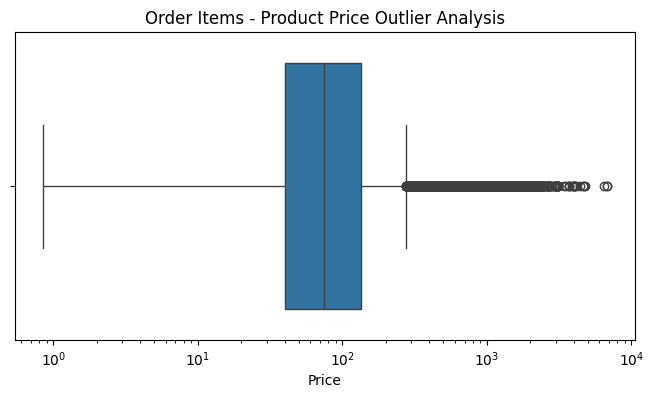

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,4))

sns.boxplot(
    x=order_items["price"]
)

plt.xscale('log')
plt.title("Order Items - Product Price Outlier Analysis")
plt.xlabel("Price")

plt.show()

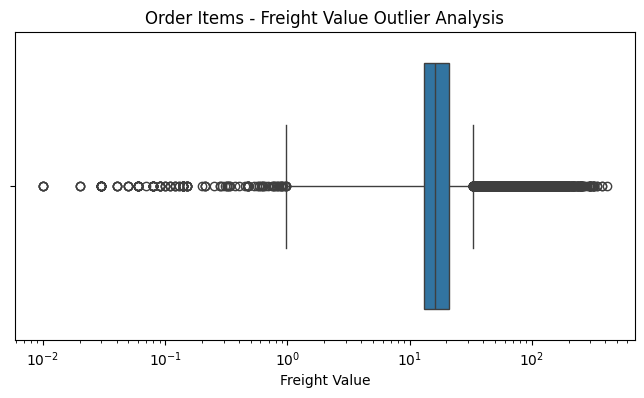

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,4))

sns.boxplot(
    x=order_items["freight_value"]
)

plt.xscale('log')
plt.title("Order Items - Freight Value Outlier Analysis")
plt.xlabel("Freight Value")

plt.show()

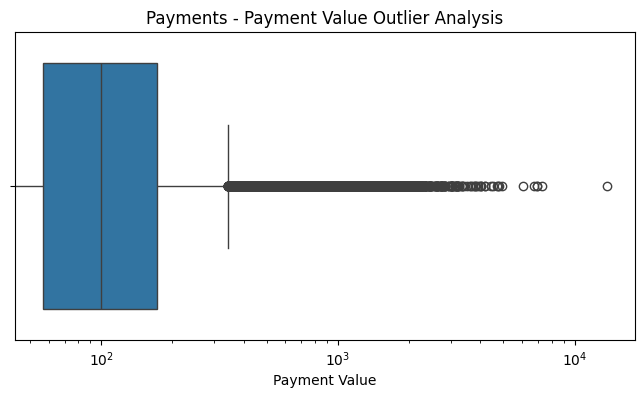

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,4))

sns.boxplot(
    x=payments["payment_value"]
)

plt.xscale('log')
plt.title("Payments - Payment Value Outlier Analysis")
plt.xlabel("Payment Value")

plt.show()

### 5a. On Orders Table — Delivery Performance Features

In [20]:
# FEATURE 1: Was this delivery late?
# Compare actual delivery date vs the estimated date promised to the customer
orders['is_late_delivery'] = (
    orders['order_delivered_customer_date'] > orders['order_estimated_delivery_date']
).astype(int)
# 1 = late, 0 = on time, NaN where delivery date is missing

# FEATURE 2: How many days late was it?
# Positive = late by X days, Negative = arrived X days early
orders['delivery_delay_days'] = (
    orders['order_delivered_customer_date'] - orders['order_estimated_delivery_date']
).dt.days

# FEATURE 3: Total actual delivery time (purchase → delivered)
orders['actual_delivery_days'] = (
    orders['order_delivered_customer_date'] - orders['order_purchase_timestamp']
).dt.days

# FEATURE 4: Time components for time-series analysis in SQL
orders['order_year']  = orders['order_purchase_timestamp'].dt.year
orders['order_month'] = orders['order_purchase_timestamp'].dt.month
orders['order_ym']    = orders['order_purchase_timestamp'].dt.to_period('M').astype(str)

# Summary
total_delivered = orders[orders['order_status'] == 'delivered']['is_late_delivery'].count()
total_late = orders[orders['order_status'] == 'delivered']['is_late_delivery'].sum()
print(f"Delivered orders    : {total_delivered:,}")
print(f"Late deliveries     : {int(total_late):,}")
print(f"Late delivery rate  : {100 * total_late / total_delivered:.1f}%")
print()
print("New columns added to orders:")
print(orders[['is_late_delivery','delivery_delay_days','actual_delivery_days','order_ym']].head(5).to_string())


Delivered orders    : 96,478
Late deliveries     : 7,826
Late delivery rate  : 8.1%

New columns added to orders:
   is_late_delivery  delivery_delay_days  actual_delivery_days order_ym
0                 0                 -8.0                   8.0  2017-10
1                 0                 -6.0                  13.0  2018-07
2                 0                -18.0                   9.0  2018-08
3                 0                -13.0                  13.0  2017-11
4                 0                -10.0                   2.0  2018-02


### 5b. On Order Items Table — Freight Economics Features

In [21]:
# FEATURE 5: Total value of item including shipping
order_items['total_item_value'] = order_items['price'] + order_items['freight_value']

# FEATURE 6: Freight as a % of total value
# High ratio = shipping costs more than the item is worth = margin drain
order_items['freight_ratio'] = order_items['freight_value'] / order_items['total_item_value']

print("Freight ratio distribution:")
print(order_items['freight_ratio'].describe().round(3))
print()
high_freight = (order_items['freight_ratio'] > 0.30).sum()
print(f"Items where freight > 30% of value: {high_freight:,} ({100*high_freight/len(order_items):.1f}%)")


Freight ratio distribution:
count    112650.000
mean          0.213
std           0.129
min           0.000
25%           0.118
50%           0.188
75%           0.282
max           0.963
Name: freight_ratio, dtype: float64

Items where freight > 30% of value: 24,434 (21.7%)


### 5c. On Payments Table — Risk Signal Features

In [22]:
# FEATURE 7: Is this a high-installment order?
# Customers splitting into 7+ payments = cash flow stress signal
payments_clean['high_installment_flag'] = (
    payments_clean['payment_installments'] > 6
).astype(int)

print("Installment distribution:")
print(payments_clean['payment_installments'].value_counts().sort_index().head(10))
print()
high_install = payments_clean['high_installment_flag'].sum()
print(f"High installment orders (>6): {high_install:,} ({100*high_install/len(payments_clean):.1f}%)")


Installment distribution:
payment_installments
0        2
1    48268
2    12363
3    10429
4     7070
5     5227
6     3908
7     1622
8     4251
9      644
Name: count, dtype: int64

High installment orders (>6): 12,173 (12.2%)


### 5d. On Reviews Table — Sentiment Flag

In [23]:
# FEATURE 8: Bad review flag
# 1 or 2 stars = bad review, directly correlates with churn risk
reviews_clean['is_bad_review'] = (reviews_clean['review_score'] <= 2).astype(int)

bad = reviews_clean['is_bad_review'].sum()
total = len(reviews_clean)
print(f"Bad reviews (1-2 stars) : {bad:,} ({100*bad/total:.1f}%)")
print(f"Good reviews (3-5 stars): {total - bad:,} ({100*(total-bad)/total:.1f}%)")


Bad reviews (1-2 stars) : 14,495 (14.7%)
Good reviews (3-5 stars): 84,178 (85.3%)


---
## Step 6 — Build the Master Table

The master table joins everything into one wide table.
This is what most of your SQL queries will run on.

**Why a master table?**
- SQL JOINs across 9 tables every time = slow and complex
- One pre-joined table = fast queries, easy to understand
- Standard practice in data warehousing (called a "fact table")


In [24]:
# Aggregate order_items to one row per order BEFORE merging
order_items_agg = order_items.groupby('order_id').agg(
    total_items        = ('order_item_id', 'count'),
    total_price        = ('price', 'sum'),
    total_freight      = ('freight_value', 'sum'),
    total_item_value   = ('total_item_value', 'sum'),
    avg_freight_ratio  = ('freight_ratio', 'mean'),
    seller_id          = ('seller_id', 'first'),   # primary seller
    product_id         = ('product_id', 'first')   # primary product
).reset_index()

# Now merge aggregated version — one row per order guaranteed
master = orders.copy()
master = master.merge(order_items_agg, on='order_id', how='left')
master = master.merge(payments_clean, on='order_id', how='left')
master = master.merge(
    reviews_clean[['order_id', 'review_score', 'is_bad_review']],
    on='order_id', how='left'
)
master = master.merge(
    customers[['customer_id', 'customer_city', 'customer_state']],
    on='customer_id', how='left'
)
master = master.merge(
    sellers[['seller_id', 'seller_city', 'seller_state']],
    on='seller_id', how='left'
)
master = master.merge(
    products_clean[['product_id', 'category_english', 'product_weight_g']],
    on='product_id', how='left'
)

print(f"Master table shape: {master.shape[0]:,} rows × {master.shape[1]} columns")
print(f"Unique orders in master: {master['order_id'].nunique():,}")
print(f"Row count should equal unique orders ✅" 
      if len(master) == master['order_id'].nunique() 
      else "⚠️ Duplicate order_ids detected — check aggregation")

Master table shape: 99,441 rows × 33 columns
Unique orders in master: 99,441
Row count should equal unique orders ✅


In [25]:
master.dtypes

order_id                                    str
customer_id                                 str
order_status                                str
order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
is_late_delivery                          int64
delivery_delay_days                     float64
actual_delivery_days                    float64
order_year                                int32
order_month                               int32
order_ym                                    str
total_items                             float64
total_price                             float64
total_freight                           float64
total_item_value                        float64
avg_freight_ratio                       float64
seller_id                                   str
product_id                              

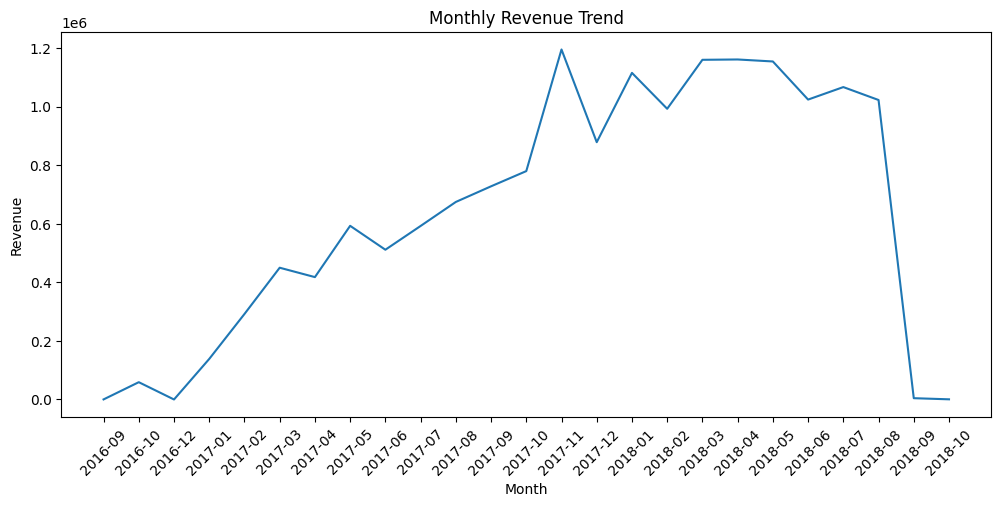

In [28]:
monthly_revenue = (
    master.groupby("order_ym")["total_payment"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(12,5))

sns.lineplot(
    data=monthly_revenue,
    x="order_ym",
    y="total_payment"
)

plt.xticks(rotation=45)
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.show()

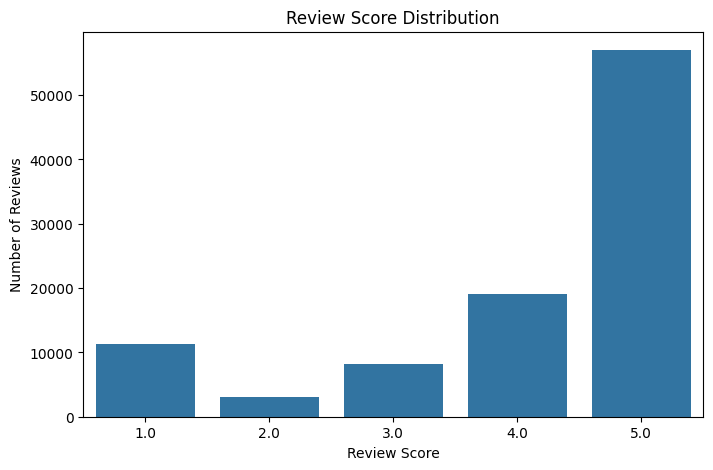

In [29]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=master,
    x="review_score"
)

plt.title("Review Score Distribution")
plt.xlabel("Review Score")
plt.ylabel("Number of Reviews")

plt.show()

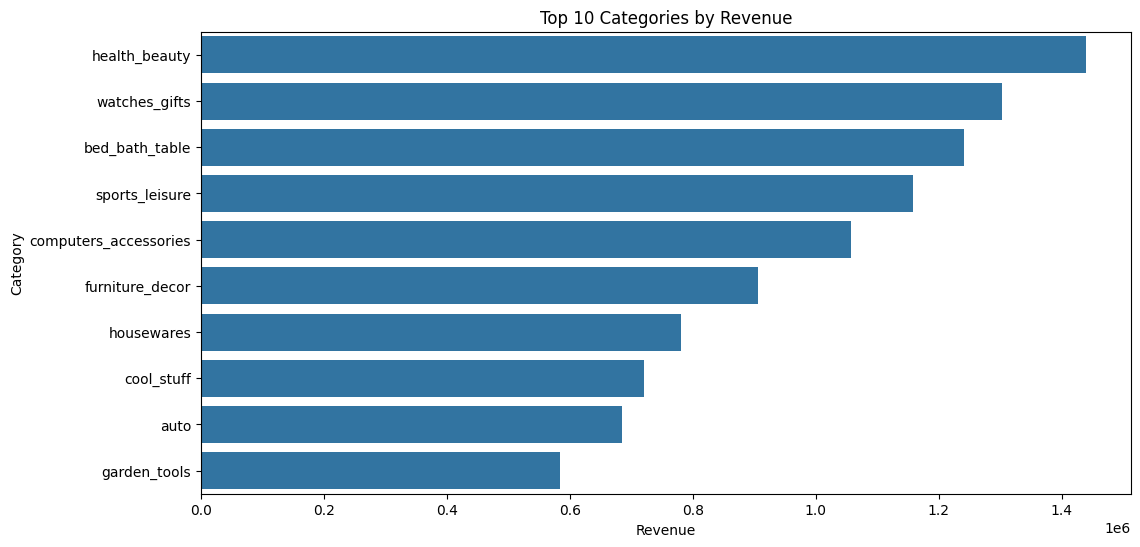

In [30]:
category_revenue = (
    master.groupby("category_english")["total_payment"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=category_revenue.values,
    y=category_revenue.index
)

plt.title("Top 10 Categories by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Category")

plt.show()

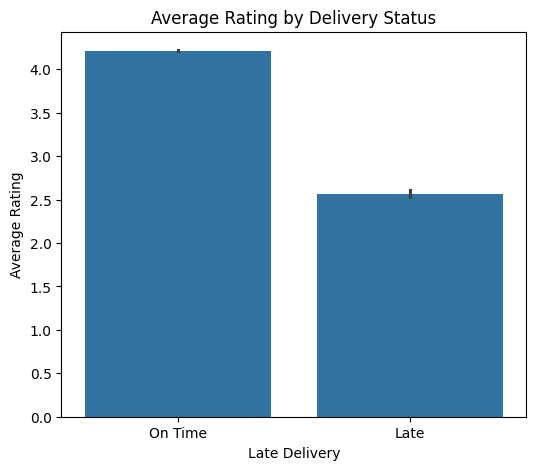

In [31]:
plt.figure(figsize=(6,5))

sns.barplot(
    data=master,
    x="is_late_delivery",
    y="review_score"
)

plt.title("Average Rating by Delivery Status")
plt.xlabel("Late Delivery")
plt.ylabel("Average Rating")

plt.xticks(
    [0,1],
    ["On Time","Late"]
)

plt.show()

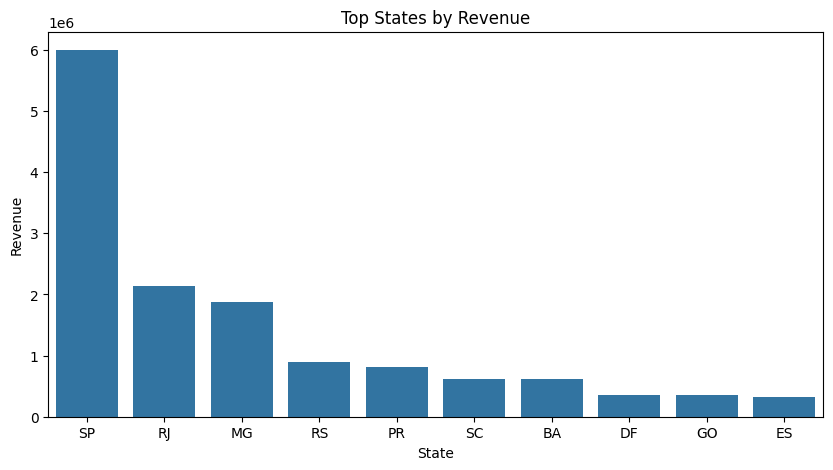

In [33]:
state_revenue = (
    master.groupby("customer_state")["total_payment"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))

sns.barplot(
    x=state_revenue.index,
    y=state_revenue.values
)

plt.title("Top States by Revenue")
plt.xlabel("State")
plt.ylabel("Revenue")

plt.show()

---
## Step 7 — Validate Before Export

Always validate before sending data anywhere. Catch problems here, not in SQL.


In [63]:
print("=" * 50)
print("VALIDATION REPORT")
print("=" * 50)

# 1. Row counts
print(f"Row counts:")
print(f"  orders       : {len(orders):,}")
print(f"  order_items  : {len(order_items):,}")
print(f"  payments     : {len(payments_clean):,}")
print(f"  reviews      : {len(reviews_clean):,}")
print(f"  customers    : {len(customers):,}")
print(f"  sellers      : {len(sellers):,}")
print(f"  products     : {len(products_clean):,}")
print(f"  master       : {len(master):,}")


# 2. Check key business columns have no unexpected nulls
print(f"Master table null check on key columns:")
order_items_agg = order_items.groupby('order_id').agg(
    total_items        = ('order_item_id', 'count'),
    total_price        = ('price', 'sum'),
    total_freight      = ('freight_value', 'sum'),
    total_item_value   = ('total_item_value', 'sum'),
    avg_freight_ratio  = ('freight_ratio', 'mean'),
    seller_id          = ('seller_id', 'first'),   # primary seller
    product_id         = ('product_id', 'first')   # primary product
).reset_index()
key_cols = ['order_id', 'order_status', 'total_price', 'seller_id', 'customer_state']
for col in key_cols:
    nulls = master[col].isnull().sum()
    pct = 100 * nulls / len(master)
    status = "✅" if pct < 5 else "⚠️"
    print(f"  {status} {col}: {nulls:,} nulls ({pct:.1f}%)")

# 3. Sanity check on engineered features
print(f"Engineered feature sanity check:")
print(f"  Late delivery values (should be 0 or 1): {master['is_late_delivery'].dropna().unique()[:5]}")
print(f"  Freight ratio range: {master['avg_freight_ratio'].min():.3f} to {master['avg_freight_ratio'].max():.3f}")
print(f"  Bad review values (should be 0 or 1): {master['is_bad_review'].dropna().unique()}")

# 4. Revenue check
total_rev = master[master['order_status'] == 'delivered']['total_price'].sum()
print(f"Total gross revenue (delivered orders): R$ {total_rev:,.0f}")


VALIDATION REPORT
Row counts:
  orders       : 99,441
  order_items  : 112,650
  payments     : 99,440
  reviews      : 98,673
  customers    : 99,441
  sellers      : 3,095
  products     : 32,951
  master       : 99,441
Master table null check on key columns:
  ✅ order_id: 0 nulls (0.0%)
  ✅ order_status: 0 nulls (0.0%)
  ✅ total_price: 775 nulls (0.8%)
  ✅ seller_id: 775 nulls (0.8%)
  ✅ customer_state: 0 nulls (0.0%)
Engineered feature sanity check:
  Late delivery values (should be 0 or 1): [0 1]
  Freight ratio range: 0.000 to 0.955
  Bad review values (should be 0 or 1): [0. 1.]
Total gross revenue (delivered orders): R$ 13,221,498


---
## Step 8 — Export Cleaned CSVs

Export each cleaned table as a CSV file into a folder called `cleaned_data/`.
These files go directly into MySQL Workbench in the next step.


In [64]:
# Create output folder if it doesn't exist
os.makedirs("cleaned_data", exist_ok=True)

# Export each table
exports = {
    "orders_clean.csv"       : orders,
    "order_items_clean.csv"  : order_items,
    "payments_clean.csv"     : payments_clean,
    "reviews_clean.csv"      : reviews_clean,
    "customers_clean.csv"    : customers,
    "sellers_clean.csv"      : sellers,
    "products_clean.csv"     : products_clean,
    "master_clean.csv"       : master,
}

for filename, df in exports.items():
    path = f"cleaned_data/{filename}"
    df.to_csv(path, index=False)
    size_kb = os.path.getsize(path) / 1024
    print(f"✅ {filename:<30} {len(df):>8,} rows   {size_kb:>8.1f} KB")

print()
print("All files exported to cleaned_data/ folder.")
print("Next step: Import these into MySQL Workbench.")


✅ orders_clean.csv                 99,441 rows    18848.4 KB
✅ order_items_clean.csv           112,650 rows    17781.4 KB
✅ payments_clean.csv               99,440 rows     5383.8 KB
✅ reviews_clean.csv                98,673 rows    13196.3 KB
✅ customers_clean.csv              99,441 rows     8458.7 KB
✅ sellers_clean.csv                 3,095 rows      162.8 KB
✅ products_clean.csv               32,951 rows     3648.3 KB
✅ master_clean.csv                 99,441 rows    37395.9 KB

All files exported to cleaned_data/ folder.
Next step: Import these into MySQL Workbench.


In [80]:
print(master.dtypes)
print(orders.dtypes)
master.head()

order_id                                    str
customer_id                                 str
order_status                                str
order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
is_late_delivery                          int64
delivery_delay_days                     float64
actual_delivery_days                    float64
order_year                                int64
order_month                               int64
order_ym                                    str
total_items                             float64
total_price                             float64
total_freight                           float64
total_item_value                        float64
avg_freight_ratio                       float64
seller_id                                   str
product_id                              

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,is_late_delivery,delivery_delay_days,...,payment_type,high_installment_flag,review_score,is_bad_review,customer_city,customer_state,seller_city,seller_state,category_english,product_weight_g
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,0,-8.0,...,voucher,0.0,4.0,0.0,sao paulo,SP,maua,SP,housewares,500.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,0,-6.0,...,boleto,0.0,4.0,0.0,barreiras,BA,belo horizonte,SP,perfumery,400.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,0,-18.0,...,credit_card,0.0,5.0,0.0,vianopolis,GO,guariba,SP,auto,420.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,0,-13.0,...,credit_card,0.0,5.0,0.0,sao goncalo do amarante,RN,belo horizonte,MG,pet_shop,450.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,0,-10.0,...,credit_card,0.0,5.0,0.0,santo andre,SP,mogi das cruzes,SP,stationery,250.0
